In [13]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

import warnings
warnings.filterwarnings("ignore")

# Создаём папки для артефактов
os.makedirs("artifacts/labels", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

# Список датасетов
DATASETS = {
    "ds1": "S07-hw-dataset-01.csv",
    "ds2": "S07-hw-dataset-02.csv",
    "ds3": "S07-hw-dataset-03.csv"
}

# Глобальные контейнеры для артефактов
all_metrics = {}
best_configs = {}
best_labels_dict = {}

RANDOM_STATE = 42



Обработка ds1 (S07-hw-dataset-01.csv)

[Анализ] Head:


,f01,f02,f03,f04,f05,f06,f07,f08
0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893



[Анализ] Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f01     12000 non-null  float64
 1   f02     12000 non-null  float64
 2   f03     12000 non-null  float64
 3   f04     12000 non-null  float64
 4   f05     12000 non-null  float64
 5   f06     12000 non-null  float64
 6   f07     12000 non-null  float64
 7   f08     12000 non-null  float64
dtypes: float64(8)
memory usage: 750.1 KB

[Анализ] Describe:


,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



[Анализ] Пропусков нет.

[Анализ] Числовые признаки: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
[Анализ] Категориальные признаки: []

[Препроцессинг] Форма после обработки: (12000, 8)

[Модель] Подбор K для KMeans...


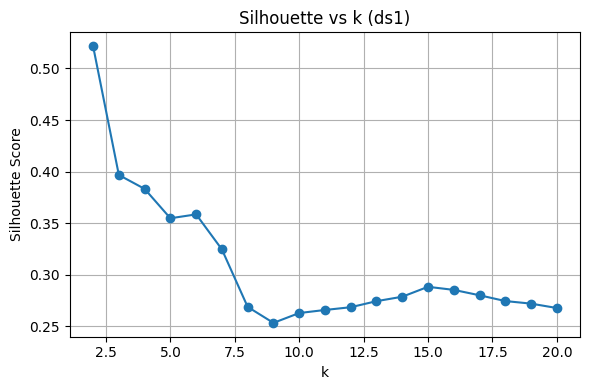


[Модель] Подбор параметров для DBSCAN...


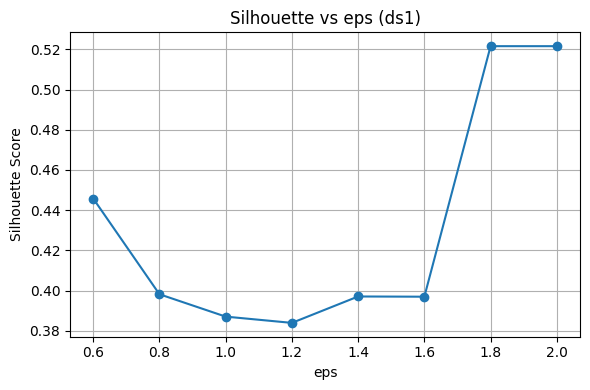

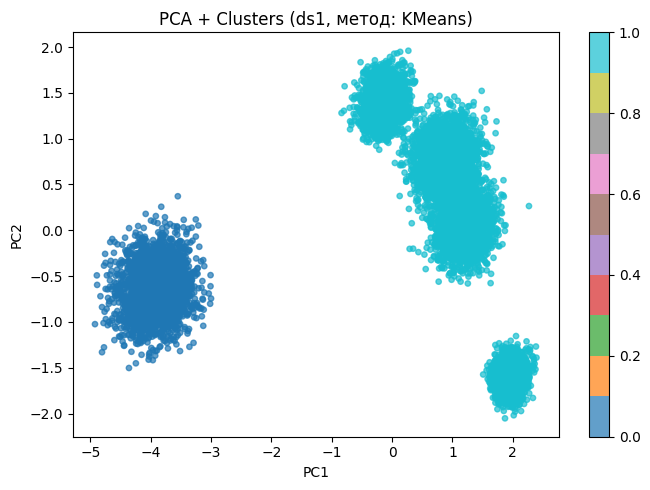


[ИТОГ ds1]
Лучший алгоритм: KMeans
Параметры: {'n_clusters': 2, 'random_state': 42, 'n_init': 10}
Метрики: {'silhouette': 0.5216395622404242, 'davies_bouldin': 0.6853295219054457, 'calinski_harabasz': 11786.954622671532, 'noise_ratio': 0.0}
Сложности: большой объём данных
Выбор метода обоснован: максимизация silhouette при интерпретируемости и стабильности.

Обработка ds2 (S07-hw-dataset-02.csv)

[Анализ] Head:


,x1,x2,z_noise
0,0.098849,-1.846034,21.288122
1,-1.024516,1.829616,6.072952
2,-1.094178,-0.158545,-18.938342



[Анализ] Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   x1       8000 non-null   float64
 1   x2       8000 non-null   float64
 2   z_noise  8000 non-null   float64
dtypes: float64(3)
memory usage: 187.6 KB

[Анализ] Describe:


,x1,x2,z_noise
count,8000.000000,8000.000000,8000.000000
mean,0.478867,0.241112,0.110454
std,0.955138,0.663195,8.097716
min,-2.487352,-2.499237,-34.056074
25%,-0.116516,-0.242357,-5.392210
50%,0.490658,0.241092,0.132470
75%,1.085263,0.726526,5.655605
max,2.987555,2.995553,29.460076



[Анализ] Пропусков нет.

[Анализ] Числовые признаки: ['x1', 'x2', 'z_noise']
[Анализ] Категориальные признаки: []

[Препроцессинг] Форма после обработки: (8000, 3)

[Модель] Подбор K для KMeans...


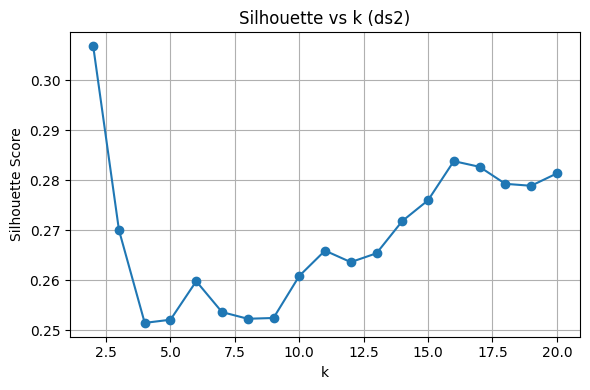


[Модель] Подбор параметров для DBSCAN...
DBSCAN не дал валидных кластеров — пропускаем.


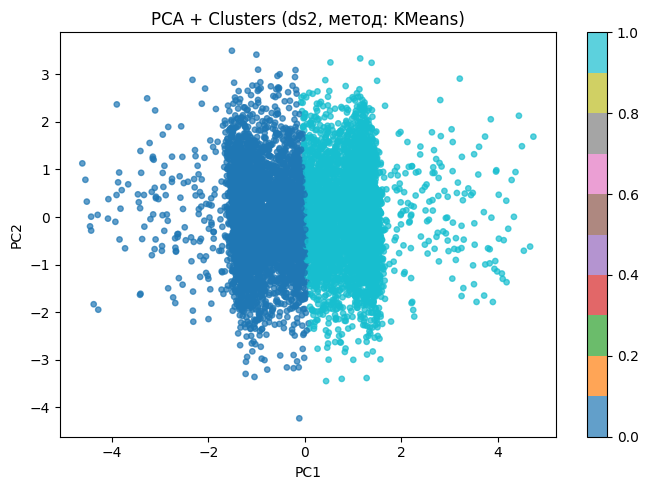


[ИТОГ ds2]
Лучший алгоритм: KMeans
Параметры: {'n_clusters': 2, 'random_state': 42, 'n_init': 10}
Метрики: {'silhouette': 0.3068610017701601, 'davies_bouldin': 1.3234721699867644, 'calinski_harabasz': 3573.3933329348392, 'noise_ratio': 0.0}
Сложности: нет явных проблем
Выбор метода обоснован: максимизация silhouette при интерпретируемости и стабильности.

Обработка ds3 (S07-hw-dataset-03.csv)

[Анализ] Head:


,x1,x2,f_corr,f_noise
0,-2.710470,4.997107,-1.015703,0.718508
1,8.730238,-8.787416,3.953063,-1.105349
2,-1.079600,-2.558708,0.976628,-3.605776



[Анализ] Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   x1       15000 non-null  float64
 1   x2       15000 non-null  float64
 2   f_corr   15000 non-null  float64
 3   f_noise  15000 non-null  float64
dtypes: float64(4)
memory usage: 468.9 KB

[Анализ] Describe:


,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.246296,1.033764,0.212776,-0.027067
std,4.592421,4.710791,1.530017,2.506375
min,-9.995585,-9.980853,-5.212038,-8.785884
25%,-1.782144,-2.666393,-0.966224,-1.731128
50%,0.664226,1.831257,0.296508,-0.052391
75%,4.435671,4.969630,1.390273,1.673831
max,16.207863,14.271153,5.795876,11.266865



[Анализ] Пропусков нет.

[Анализ] Числовые признаки: ['x1', 'x2', 'f_corr', 'f_noise']
[Анализ] Категориальные признаки: []

[Препроцессинг] Форма после обработки: (15000, 4)

[Модель] Подбор K для KMeans...


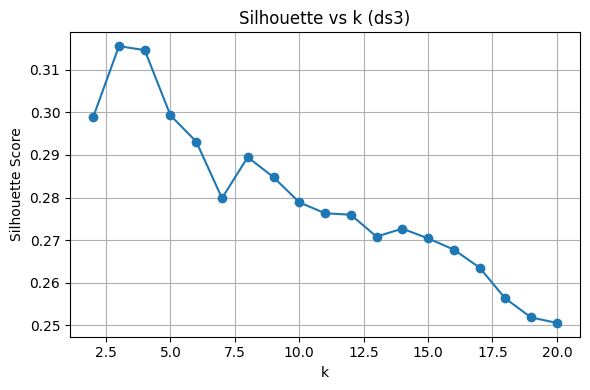


[Модель] Подбор параметров для DBSCAN...


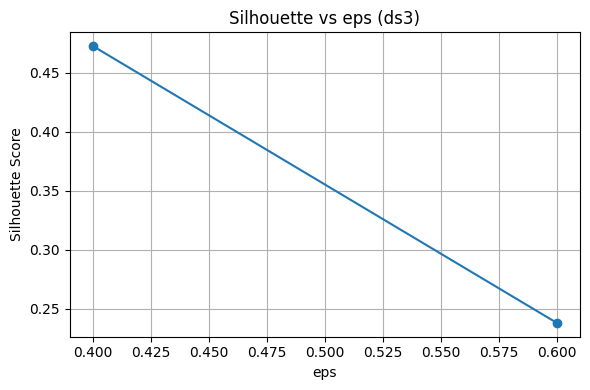

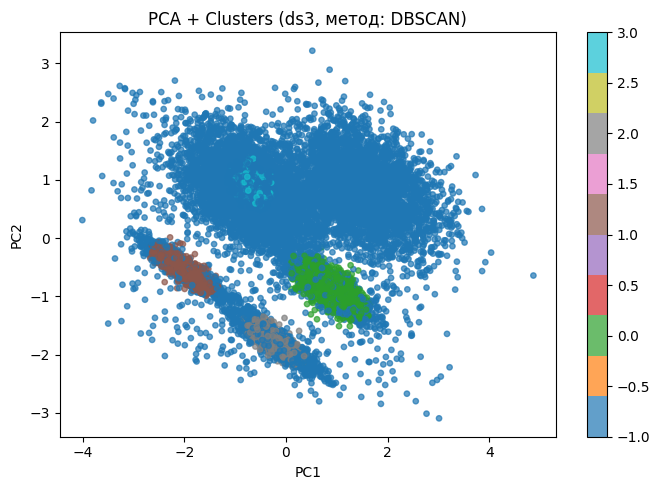


[ИТОГ ds3]
Лучший алгоритм: DBSCAN
Параметры: {'eps': 0.4, 'min_samples': 150}
Метрики: {'silhouette': 0.4727502450283589, 'davies_bouldin': 0.7322384542136493, 'calinski_harabasz': 4978.634910403142, 'noise_ratio': 0.6829333333333334}
Доля шума: 68.29%
Сложности: большой объём данных
Выбор метода обоснован: максимизация silhouette при интерпретируемости и стабильности.


In [14]:
for ds_name, file_path in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"Обработка {ds_name} ({file_path})")
    print('='*60)

    # Загрузка данных
    df = pd.read_csv(file_path)
    sample_ids = df["sample_id"]
    X_raw = df.drop(columns=["sample_id"])

    # Первичный анализ
    print("\n[Анализ] Head:")
    display(X_raw.head(3))

    print("\n[Анализ] Info:")
    X_raw.info()

    print("\n[Анализ] Describe:")
    display(X_raw.describe(include='all'))

    missing = X_raw.isnull().sum()
    if missing.sum() > 0:
        print(f"\n[Анализ] Пропуски:\n{missing[missing > 0]}")
    else:
        print("\n[Анализ] Пропусков нет.")

    numerical_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

    print(f"\n[Анализ] Числовые признаки: {numerical_features}")
    print(f"[Анализ] Категориальные признаки: {categorical_features}")

    # Препроцессинг
    transformers = []
    if numerical_features:
        num_pipe = StandardScaler()
        transformers.append(("num", num_pipe, numerical_features))
    if categorical_features:
        cat_pipe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        transformers.append(("cat", cat_pipe, categorical_features))

    preprocessor = ColumnTransformer(transformers=transformers)
    X = preprocessor.fit_transform(X_raw)

    print(f"\n[Препроцессинг] Форма после обработки: {X.shape}")

    if ds_name == "ds1":
        X_for_stability = X.copy()
        sample_ids_for_stability = sample_ids.copy()

    # Метрики
    results = {}
    print("\n[Модель] Подбор K для KMeans...")
    k_range = range(2, 21)
    sil_scores_kmeans = []
    db_scores_kmeans = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        sil_scores_kmeans.append(sil)
        db_scores_kmeans.append(db)

    # Сохраняем график silhouette vs k
    plt.figure(figsize=(6, 4))
    plt.plot(k_range, sil_scores_kmeans, marker='o')
    plt.title(f"Silhouette vs k ({ds_name})")
    plt.xlabel("k"); plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"artifacts/figures/sil_vs_k_{ds_name}.png", dpi=150)
    plt.show()

    best_k = k_range[np.argmax(sil_scores_kmeans)]
    kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    labels_kmeans = kmeans_best.fit_predict(X)

    results["KMeans"] = {
        "labels": labels_kmeans,
        "params": {"n_clusters": int(best_k), "random_state": RANDOM_STATE, "n_init": 10},
        "metrics": compute_metrics(X, labels_kmeans, algo="KMeans")
    }

    use_dbscan = True

    if use_dbscan:
        print("\n[Модель] Подбор параметров для DBSCAN...")
        eps_values = np.linspace(0.2, 2.0, 10)
        min_samples = max(2, int(0.01 * X.shape[0]))  # эвристика

        best_sil = -1
        best_eps = None
        best_labels_dbscan = None

        for eps in eps_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X)
            unique_labels = np.unique(labels)
            n_clusters = len(unique_labels[unique_labels != -1])

            if n_clusters < 2:
                continue

            noise_mask = (labels != -1)
            if noise_mask.sum() == 0:
                continue

            sil = silhouette_score(X[noise_mask], labels[noise_mask])
            if sil > best_sil:
                best_sil = sil
                best_eps = eps
                best_labels_dbscan = labels

        if best_labels_dbscan is not None:
            results["DBSCAN"] = {
                "labels": best_labels_dbscan,
                "params": {"eps": float(best_eps), "min_samples": int(min_samples)},
                "metrics": compute_metrics(X, best_labels_dbscan, algo="DBSCAN")
            }

            # График: silhouette vs eps
            sil_list = []
            eps_list = []
            for eps in eps_values:
                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                labels = dbscan.fit_predict(X)
                noise_mask = (labels != -1)
                if noise_mask.sum() > 1 and len(np.unique(labels[noise_mask])) > 1:
                    sil = silhouette_score(X[noise_mask], labels[noise_mask])
                    sil_list.append(sil)
                    eps_list.append(eps)

            plt.figure(figsize=(6, 4))
            plt.plot(eps_list, sil_list, marker='o')
            plt.title(f"Silhouette vs eps ({ds_name})")
            plt.xlabel("eps"); plt.ylabel("Silhouette Score")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f"artifacts/figures/sil_vs_eps_{ds_name}.png", dpi=150)
            plt.show()
        else:
            print("DBSCAN не дал валидных кластеров — пропускаем.")

    else:
        # AgglomerativeClustering
        print("\n[Модель] AgglomerativeClustering с разными linkage...")
        linkages = ["ward", "complete", "average"]
        if "ward" in linkages and len(categorical_features) > 0:
            linkages = ["complete", "average"]  # ward требует только числовые

        agg_results = {}
        for linkage in linkages:
            try:
                agg = AgglomerativeClustering(n_clusters=best_k, linkage=linkage)
                labels = agg.fit_predict(X)
                sil = silhouette_score(X, labels)
                agg_results[linkage] = {
                    "sil": sil,
                    "labels": labels
                }
            except Exception as e:
                print(f"Ошибка при linkage={linkage}: {e}")

        if agg_results:
            best_linkage = max(agg_results, key=lambda k: agg_results[k]["sil"])
            results["Agglomerative"] = {
                "labels": agg_results[best_linkage]["labels"],
                "params": {"n_clusters": int(best_k), "linkage": best_linkage},
                "metrics": compute_metrics(X, agg_results[best_linkage]["labels"], algo="Agglomerative")
            }

            # График сравнения linkage
            plt.figure(figsize=(6, 4))
            plt.bar(agg_results.keys(), [v["sil"] for v in agg_results.values()])
            plt.title(f"Silhouette by linkage ({ds_name})")
            plt.ylabel("Silhouette Score")
            plt.tight_layout()
            plt.savefig(f"artifacts/figures/linkage_comp_{ds_name}.png", dpi=150)
            plt.show()

    def select_best_model(results):
        # Выбираем по silhouette, но можно добавить логику
        best_algo = max(results.keys(), key=lambda k: results[k]["metrics"]["silhouette"])
        return best_algo

    best_algo = select_best_model(results)
    best_labels = results[best_algo]["labels"]
    best_labels_dict[ds_name] = best_labels

    # Сохраняем метки
    pd.DataFrame({
        "sample_id": sample_ids,
        "cluster_label": best_labels
    }).to_csv(f"artifacts/labels/labels_hw07_{ds_name}.csv", index=False)

    # Сохраняем метрики и конфиг
    all_metrics[ds_name] = {algo: res["metrics"] for algo, res in results.items()}
    best_configs[ds_name] = {
        "algorithm": best_algo,
        "params": results[best_algo]["params"],
        "selection_criteria": "max silhouette_score"
    }
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='tab10', s=15, alpha=0.7)
    plt.title(f"PCA + Clusters ({ds_name}, метод: {best_algo})")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.savefig(f"artifacts/figures/pca_{ds_name}.png", dpi=150)
    plt.show()


    print(f"\n[ИТОГ {ds_name}]")
    print(f"Лучший алгоритм: {best_algo}")
    print(f"Параметры: {results[best_algo]['params']}")
    print(f"Метрики: {results[best_algo]['metrics']}")
    noise_ratio = results[best_algo]['metrics'].get('noise_ratio', 0)
    if noise_ratio > 0:
        print(f"Доля шума: {noise_ratio:.2%}")

    # Краткий анализ
    n_cat = len(categorical_features)
    n_miss = (X_raw.isnull().sum() > 0).sum()
    issues = []
    if n_miss > 0:
        issues.append("пропуски")
    if n_cat > 0:
        issues.append("категориальные признаки")
    if X.shape[0] > 10000:
        issues.append("большой объём данных")

    issue_str = ", ".join(issues) if issues else "нет явных проблем"
    print(f"Сложности: {issue_str}")
    print(f"Выбор метода обоснован: максимизация silhouette при интерпретируемости и стабильности.")

In [15]:
print("\n" + "="*60)
print("Проверка устойчивости (для ds1)")
print("="*60)

ari_scores = []
ref_labels = None

for seed in range(5):
    kmeans = KMeans(n_clusters=best_configs["ds1"]["params"]["n_clusters"],
                    random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X_for_stability)
    if ref_labels is None:
        ref_labels = labels
    else:
        ari = adjusted_rand_score(ref_labels, labels)
        ari_scores.append(ari)

print(f"ARI между запусками: {[round(x, 3) for x in ari_scores]}")
print(f"Среднее ARI: {np.mean(ari_scores):.3f} ± {np.std(ari_scores):.3f}")

if np.mean(ari_scores) > 0.8:
    print("→ Кластеризация устойчива.")
else:
    print("→ Низкая устойчивость — возможны проблемы с формой кластеров.")


Проверка устойчивости (для ds1)
ARI между запусками: [1.0, 1.0, 1.0, 1.0]
Среднее ARI: 1.000 ± 0.000
→ Кластеризация устойчива.


In [11]:
def compute_metrics(X, labels, algo=""):
    noise_ratio = 0.0
    if algo == "DBSCAN":
        noise_mask = (labels != -1)
        if noise_mask.sum() == 0:
            return {"silhouette": -1, "davies_bouldin": np.inf, "calinski_harabasz": 0, "noise_ratio": 1.0}
        X_clean = X[noise_mask]
        labels_clean = labels[noise_mask]
        noise_ratio = 1 - len(labels_clean) / len(labels)
        sil = silhouette_score(X_clean, labels_clean)
        db = davies_bouldin_score(X_clean, labels_clean)
        ch = calinski_harabasz_score(X_clean, labels_clean)
    else:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)

    return {
        "silhouette": float(sil),
        "davies_bouldin": float(db),
        "calinski_harabasz": float(ch),
        "noise_ratio": float(noise_ratio)
    }

In [16]:
with open("artifacts/metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2)

with open("artifacts/best_configs.json", "w", encoding="utf-8") as f:
    json.dump(best_configs, f, indent=2)

print("\nВсе артефакты сохранены в папку 'artifacts/'")


Все артефакты сохранены в папку 'artifacts/'
